In [67]:
# Cell 1: Imports
# This notebook trains a production-ready XGBoost classifier for RecruitIQ.
import importlib.util
import subprocess
import sys
import time
import warnings
from pathlib import Path

if importlib.util.find_spec("xgboost") is None:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "xgboost",
    ])

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import randint, uniform
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GroupKFold,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
    learning_curve,
    train_test_split,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=UserWarning)
plt.style.use("seaborn-v0_8-whitegrid")

In [68]:
# Cell 2: Configuration
# Central configuration keeps paths, random state, and model settings reproducible.
RANDOM_SEED = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
TUNING_ITERATIONS = 25
LABEL_COLUMN = "label"


def find_project_root(start_path):
    """Find the RecruitIQ project root from either the repo root or ml folder."""
    start_path = Path(start_path).resolve()
    for candidate in [start_path, *start_path.parents]:
        dataset_candidate = candidate / "backend" / "app" / "datasets" / "matching_dataset.csv"
        if dataset_candidate.exists():
            return candidate
    raise FileNotFoundError("Could not find backend/app/datasets/matching_dataset.csv")


PROJECT_ROOT = find_project_root(Path.cwd())
DATASET_PATH = PROJECT_ROOT / "backend" / "app" / "datasets" / "matching_dataset.csv"
MODEL_DIR = PROJECT_ROOT / "backend" / "app" / "models"
MODEL_PATH = MODEL_DIR / "xgboost_model.pkl"
FEATURE_COLUMNS_PATH = MODEL_DIR / "feature_columns.pkl"

np.random.seed(RANDOM_SEED)

print(f"Project root : {PROJECT_ROOT}")
print(f"Dataset path : {DATASET_PATH}")
print(f"Model path   : {MODEL_PATH}")

Project root : D:\Projects\RecruitIQ
Dataset path : D:\Projects\RecruitIQ\backend\app\datasets\matching_dataset.csv
Model path   : D:\Projects\RecruitIQ\backend\app\models\xgboost_model.pkl


In [69]:
# Cell 3: Load Dataset
# The notebook uses the existing RecruitIQ dataset only; no data is regenerated.
if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATASET_PATH}")

dataset = pd.read_csv(DATASET_PATH)

print(f"Loaded dataset with {dataset.shape[0]} rows and {dataset.shape[1]} columns.")
display(dataset.head())

Loaded dataset with 3136 rows and 20 columns.


,resume_name,job_id,company,title,matched_skill_count,missing_skill_count,resume_skill_count,job_skill_count,skill_overlap_ratio,experience_gap,education_gap,project_match_count,certification_match_count,matched_skills,missing_skills,retrieval_score,title_similarity,keyword_similarity,technical_job_score,label
0,26456899.pdf,3610596223,NaN,Commercial Auto Underwriter Assistant,3,6,10,9,0.3333,0,1,0,0,"Communication, Excel, C","iOS SDK, Work Ethic, Make, Apache Solr, Teamwo...",0.3644,0.00,0.0390,0.0,1
1,23438227.pdf,3184403524,San José Clinic,Events & Communications Assistant,2,12,4,14,0.1429,0,0,3,0,"Excel, C","iOS SDK, Communication, Creativity, Automated ...",0.4257,0.25,0.0142,0.0,1
2,25608963.pdf,3520238337,Grant Writing Solutions,Grants Writer - Subcontract,1,4,9,5,0.2000,0,0,0,0,Communication,"Apache Solr, iOS SDK, Mentoring, Attention to ...",0.3604,0.00,0.0077,0.0,0
3,17043822.pdf,974774701,Kate Meadows Writing and Editing,Blog writer and virtual assistant,1,4,11,5,0.2000,0,0,1,0,Communication,"iOS SDK, Black, Coaching, Time Management",0.3908,0.00,0.0155,0.0,1
4,15139979.pdf,2195921577,NaN,Associate Planner,2,11,9,13,0.1538,0,0,3,0,"Problem Solving, Leadership","iOS SDK, Excel, Work Ethic, Communication, Str...",0.3811,0.00,0.0070,8.0,1


In [70]:
# Cell 4: Dataset Validation
# Validate schema, missing values, data types, and class balance before modeling.
if LABEL_COLUMN not in dataset.columns:
    raise ValueError(f"Target column '{LABEL_COLUMN}' is missing from the dataset.")

shape_summary = pd.DataFrame(
    {
        "metric": ["rows", "columns"],
        "value": [dataset.shape[0], dataset.shape[1]],
    }
)
missing_values = dataset.isna().sum().to_frame("missing_count")
missing_values["missing_percent"] = (
    missing_values["missing_count"] / len(dataset) * 100
).round(2)
data_types = dataset.dtypes.astype(str).to_frame("dtype")
class_balance = (
    dataset[LABEL_COLUMN]
    .value_counts(dropna=False)
    .rename_axis("label")
    .reset_index(name="count")
)
class_balance["percentage"] = (class_balance["count"] / len(dataset) * 100).round(2)

print("Dataset shape")
display(shape_summary)
print("Missing values")
display(missing_values[missing_values["missing_count"] > 0])
print("Data types")
display(data_types)
print("Class balance")
display(class_balance)

if dataset[LABEL_COLUMN].isna().any():
    raise ValueError("Target column contains missing values.")

Dataset shape


,metric,value
0,rows,3136
1,columns,20


Missing values


,missing_count,missing_percent
company,489,15.59
matched_skills,1051,33.51
missing_skills,86,2.74


Data types


,dtype
resume_name,str
job_id,int64
company,str
title,str
matched_skill_count,int64
missing_skill_count,int64
resume_skill_count,int64
job_skill_count,int64
skill_overlap_ratio,float64
experience_gap,int64


Class balance


,label,count,percentage
0,1,1568,50.0
1,0,1568,50.0


In [71]:
# Cell 5: Feature Selection
# Only approved numerical features are used; identifiers and leakage-prone columns are excluded.
# ML AUDIT: removed skill_score, education_score, experience_score, project_score,
# certification_score (matching-engine scores = target leakage).
# Added technical_job_score (safe retrieval-time feature).
FEATURE_COLUMNS = [
    "matched_skill_count",
    "missing_skill_count",
    "resume_skill_count",
    "job_skill_count",
    "skill_overlap_ratio",
    "experience_gap",
    "education_gap",
    "project_match_count",
    "certification_match_count",
    "retrieval_score",
    "title_similarity",
    "keyword_similarity",
    "technical_job_score",
]

# Columns that must NEVER be used as model features.
EXCLUDED_COLUMNS = [
    "resume_name",
    "job_id",
    "company",
    "title",
    "matched_skills",
    "missing_skills",
    "label",
]

# Leaked columns that were removed from the dataset during the ML audit.
LEAKED_COLUMNS = [
    "skill_score",
    "education_score",
    "experience_score",
    "project_score",
    "certification_score",
    "overall_score",
    "confidence",
    "recommendation",
]

leaked_present = [col for col in LEAKED_COLUMNS if col in dataset.columns]
if leaked_present:
    raise ValueError(f"LEAKAGE DETECTED: {leaked_present} found in dataset!")

missing_feature_columns = [col for col in FEATURE_COLUMNS if col not in dataset.columns]
if missing_feature_columns:
    raise ValueError(f"Missing feature columns: {missing_feature_columns}")

feature_overlap = set(FEATURE_COLUMNS).intersection(EXCLUDED_COLUMNS)
if feature_overlap:
    raise ValueError(f"Forbidden columns selected as features: {sorted(feature_overlap)}")

X = dataset[FEATURE_COLUMNS].copy()
y = dataset[LABEL_COLUMN].astype(int).copy()

if not set(y.unique()).issubset({0, 1}):
    raise ValueError("Target must be binary with values 0 and 1.")

X = X.apply(pd.to_numeric, errors="raise")
if X.isna().any().any():
    raise ValueError("Selected features contain missing values.")

print(f"Selected {X.shape[1]} model features.")
print(f"X shape: {X.shape}")
print(f"y distribution:")
print(y.value_counts())
print(f"\nMissing values per feature:")
print(X.isna().sum())
print()
display(X.describe().T)

Selected 13 model features.
X shape: (3136, 13)
y distribution:
label
1    1568
0    1568
Name: count, dtype: int64

Missing values per feature:
matched_skill_count          0
missing_skill_count          0
resume_skill_count           0
job_skill_count              0
skill_overlap_ratio          0
experience_gap               0
education_gap                0
project_match_count          0
certification_match_count    0
retrieval_score              0
title_similarity             0
keyword_similarity           0
technical_job_score          0
dtype: int64



,count,mean,std,min,25%,50%,75%,max
matched_skill_count,3136.0,0.978316,0.949528,0.0000,0.0000,1.0000,1.0000,7.0000
missing_skill_count,3136.0,6.874043,3.167380,0.0000,5.0000,6.0000,8.0000,24.0000
resume_skill_count,3136.0,8.411990,6.431574,0.0000,5.0000,6.0000,10.0000,37.0000
job_skill_count,3136.0,7.852360,3.580233,0.0000,6.0000,7.0000,9.0000,26.0000
skill_overlap_ratio,3136.0,0.119752,0.109834,0.0000,0.0000,0.1250,0.1818,0.6667
experience_gap,3136.0,0.129783,0.784251,0.0000,0.0000,0.0000,0.0000,25.0000
education_gap,3136.0,0.036033,0.232131,0.0000,0.0000,0.0000,0.0000,4.0000
project_match_count,3136.0,0.679209,0.993967,0.0000,0.0000,0.0000,1.0000,8.0000
certification_match_count,3136.0,0.131378,0.432298,0.0000,0.0000,0.0000,0.0000,2.0000
retrieval_score,3136.0,0.344894,0.049898,0.1565,0.3008,0.3432,0.3754,0.5547


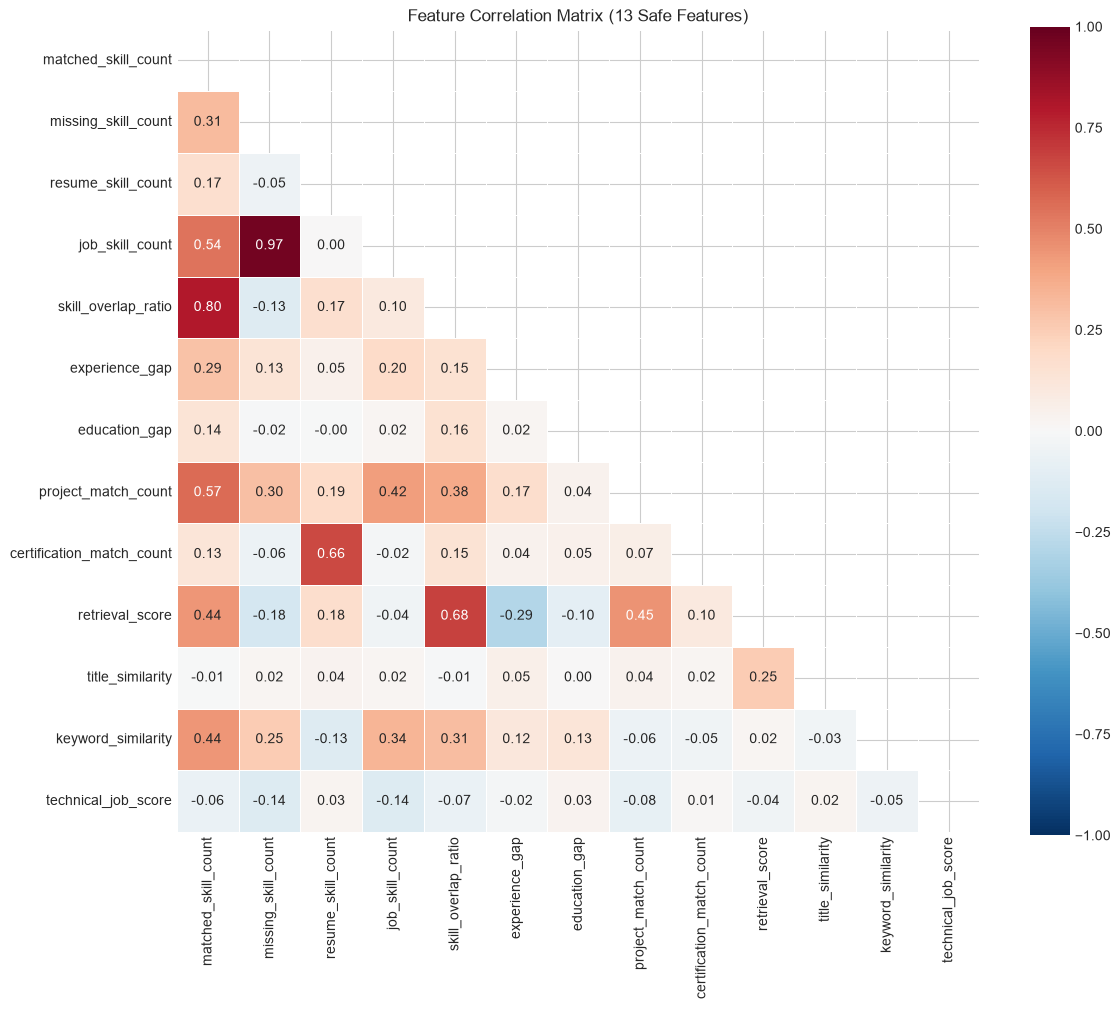

Highly correlated feature pairs (|r| >= 0.85):
  missing_skill_count <-> job_skill_count: 0.9678


In [72]:
# Cell 6: Feature Correlation Matrix
# Check for redundant features before training. High correlation (>0.85)
# between features would indicate redundancy worth investigating.
correlation_matrix = X.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Feature Correlation Matrix (13 Safe Features)")
plt.tight_layout()
plt.show()

# Flag highly correlated pairs
high_corr_threshold = 0.85
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        corr_val = abs(correlation_matrix.iloc[i, j])
        if corr_val >= high_corr_threshold:
            high_corr_pairs.append(
                (correlation_matrix.columns[i], correlation_matrix.columns[j], round(corr_val, 4))
            )

if high_corr_pairs:
    print("Highly correlated feature pairs (|r| >= 0.85):")
    for f1, f2, r in high_corr_pairs:
        print(f"  {f1} <-> {f2}: {r}")
else:
    print("No highly correlated feature pairs detected (threshold: 0.85).")

In [73]:
# Cell 6: Train Test Split
# Stratification preserves the 50/50 label distribution in both train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y,
)

split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(X_train), len(X_test)],
        "positive_rate": [y_train.mean(), y_test.mean()],
    }
)
split_summary["positive_rate"] = split_summary["positive_rate"].round(4)

display(split_summary)

,split,rows,positive_rate
0,train,2508,0.5
1,test,628,0.5


In [74]:
# Cell 7: Baseline XGBoost Model
# The baseline uses conservative regularized tree settings before tuning.
baseline_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.90,
    colsample_bytree=0.90,
    min_child_weight=2,
    gamma=0.0,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method="hist",
)

baseline_model

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [75]:
# Cell 8: Training
# Train the baseline model and keep timing for the final project summary.
baseline_start_time = time.perf_counter()
baseline_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
baseline_training_time = time.perf_counter() - baseline_start_time

print(f"Baseline training time: {baseline_training_time:.2f} seconds")

Baseline training time: 0.81 seconds


In [76]:
# Cell 9: Baseline Evaluation
# Evaluate standard binary classification metrics on the held-out test set.
def evaluate_model(model, features, labels, threshold=0.50):
    probabilities = model.predict_proba(features)[:, 1]
    predictions = (probabilities >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
        "roc_auc": roc_auc_score(labels, probabilities),
    }


baseline_metrics = evaluate_model(baseline_model, X_test, y_test)
baseline_metrics_table = pd.DataFrame([baseline_metrics], index=["baseline"]).round(4)

display(baseline_metrics_table)

,accuracy,precision,recall,f1,roc_auc
baseline,0.9968,0.9937,1.0,0.9968,0.9998


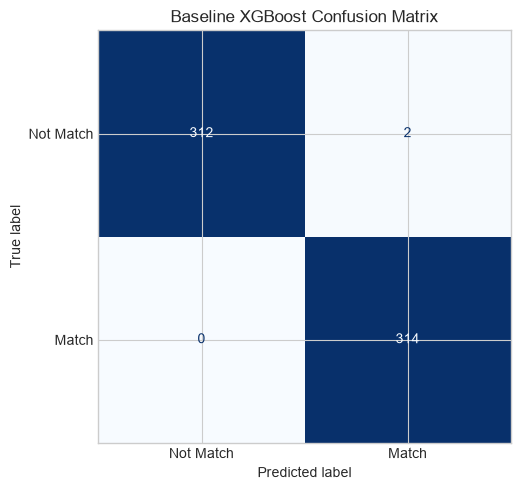

In [77]:
# Cell 10: Confusion Matrix
# The confusion matrix shows the exact true/false positive and negative counts.
baseline_probabilities = baseline_model.predict_proba(X_test)[:, 1]
baseline_predictions = (baseline_probabilities >= 0.50).astype(int)
baseline_confusion_matrix = confusion_matrix(y_test, baseline_predictions)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=baseline_confusion_matrix,
    display_labels=["Not Match", "Match"],
).plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)
ax.set_title("Baseline XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

In [78]:
# Cell 11: Classification Report
# The report provides per-class precision, recall, and F1-score.
print(classification_report(y_test, baseline_predictions, target_names=["Not Match", "Match"]))

              precision    recall  f1-score   support

   Not Match       1.00      0.99      1.00       314
       Match       0.99      1.00      1.00       314

    accuracy                           1.00       628
   macro avg       1.00      1.00      1.00       628
weighted avg       1.00      1.00      1.00       628



In [79]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_results = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False,
)

cv_report = pd.DataFrame(
    {
        metric: cv_results[f"test_{metric}"]
        for metric in scoring
    }
)

cv_summary = pd.DataFrame(
    {
        "mean": cv_report.mean(),
        "standard_deviation": cv_report.std(ddof=1),
    }
).round(4)

print("Fold-level scores")
display(cv_report.round(4))

print("Cross-validation summary")
display(cv_summary)

Fold-level scores


,accuracy,precision,recall,f1,roc_auc
0,0.998,0.9960,1.000,0.9980,0.9997
1,0.994,0.9921,0.996,0.9940,1.0000
2,0.994,0.9960,0.992,0.9940,0.9999
3,0.990,0.9842,0.996,0.9901,0.9995
4,0.996,0.9921,1.000,0.9960,0.9990


Cross-validation summary


,mean,standard_deviation
accuracy,0.9944,0.0030
precision,0.9921,0.0048
recall,0.9968,0.0033
f1,0.9944,0.0030
roc_auc,0.9996,0.0004


In [80]:
# Cell 13: Hyperparameter Tuning
# RandomizedSearchCV explores a controlled search space without excessive runtime.
tuning_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_SEED,
    n_jobs=1,
    tree_method="hist",
)

parameter_distributions = {
    "n_estimators": randint(120, 361),
    "max_depth": randint(2, 7),
    "learning_rate": uniform(0.02, 0.13),
    "subsample": uniform(0.70, 0.30),
    "colsample_bytree": uniform(0.70, 0.30),
    "min_child_weight": randint(1, 8),
    "gamma": uniform(0.0, 0.50),
}

tuning_cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
randomized_search = RandomizedSearchCV(
    estimator=tuning_model,
    param_distributions=parameter_distributions,
    n_iter=TUNING_ITERATIONS,
    scoring="roc_auc",
    cv=tuning_cv,
    random_state=RANDOM_SEED,
    n_jobs=1,
    verbose=1,
    refit=True,
    return_train_score=True,
)

tuning_start_time = time.perf_counter()
randomized_search.fit(X_train, y_train)
tuning_time = time.perf_counter() - tuning_start_time

search_results = pd.DataFrame(randomized_search.cv_results_)
search_columns = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "params",
]

print(f"Tuning time: {tuning_time:.2f} seconds")
print(f"Best CV ROC AUC: {randomized_search.best_score_:.4f}")
display(search_results[search_columns].sort_values("rank_test_score").head(10))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Tuning time: 23.95 seconds
Best CV ROC AUC: 1.0000


,rank_test_score,mean_test_score,std_test_score,mean_train_score,params
4,1,0.999990,0.000013,1.000000,"{'colsample_bytree': 0.8368209952651107, 'gamm..."
9,2,0.999984,0.000025,1.000000,"{'colsample_bytree': 0.8793699936433255, 'gamm..."
24,3,0.999981,0.000031,1.000000,"{'colsample_bytree': 0.7110660842063597, 'gamm..."
21,4,0.999978,0.000037,1.000000,"{'colsample_bytree': 0.7020856391593572, 'gamm..."
2,5,0.999975,0.000043,1.000000,"{'colsample_bytree': 0.9497327922401264, 'gamm..."
23,6,0.999952,0.000066,1.000000,"{'colsample_bytree': 0.7761746241803034, 'gamm..."
15,7,0.999939,0.000071,1.000000,"{'colsample_bytree': 0.9915136286167311, 'gamm..."
12,8,0.999927,0.000082,1.000000,"{'colsample_bytree': 0.7042239468145253, 'gamm..."
7,9,0.999860,0.000165,0.999996,"{'colsample_bytree': 0.7103165563345655, 'gamm..."
10,10,0.999841,0.000215,1.000000,"{'colsample_bytree': 0.8166031869068445, 'gamm..."


In [81]:
# Cell 14: Train Best Model
# Refit the selected configuration on the full training split before final testing.
best_parameters = randomized_search.best_params_
best_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    tree_method="hist",
    **best_parameters,
)

best_training_start_time = time.perf_counter()
best_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
best_training_time = time.perf_counter() - best_training_start_time
best_metrics = evaluate_model(best_model, X_test, y_test)

print(f"Best model training time: {best_training_time:.2f} seconds")
print("Best parameters")
display(pd.DataFrame([best_parameters]).T.rename(columns={0: "value"}))

Best model training time: 0.37 seconds
Best parameters


,value
colsample_bytree,0.836821
gamma,0.392588
learning_rate,0.045958
max_depth,5.000000
min_child_weight,1.000000
n_estimators,250.000000
subsample,0.957982


In [82]:
# Cell 15: Compare Baseline vs Best Model
# Compare held-out metrics to confirm whether tuning improved generalization.
comparison_table = pd.DataFrame(
    [baseline_metrics, best_metrics],
    index=["baseline", "best_model"],
).round(4)
comparison_table["f1_delta_vs_baseline"] = (
    comparison_table["f1"] - comparison_table.loc["baseline", "f1"]
).round(4)
comparison_table["roc_auc_delta_vs_baseline"] = (
    comparison_table["roc_auc"] - comparison_table.loc["baseline", "roc_auc"]
).round(4)

display(comparison_table)

,accuracy,precision,recall,f1,roc_auc,f1_delta_vs_baseline,roc_auc_delta_vs_baseline
baseline,0.9968,0.9937,1.0,0.9968,0.9998,0.0000,0.0000
best_model,0.9984,0.9968,1.0,0.9984,1.0000,0.0016,0.0002


Feature importance table


,feature,importance
0,matched_skill_count,0.429789
4,skill_overlap_ratio,0.210535
11,keyword_similarity,0.072439
1,missing_skill_count,0.061889
9,retrieval_score,0.054267
7,project_match_count,0.044423
8,certification_match_count,0.029762
5,experience_gap,0.023337
3,job_skill_count,0.021923
6,education_gap,0.020894


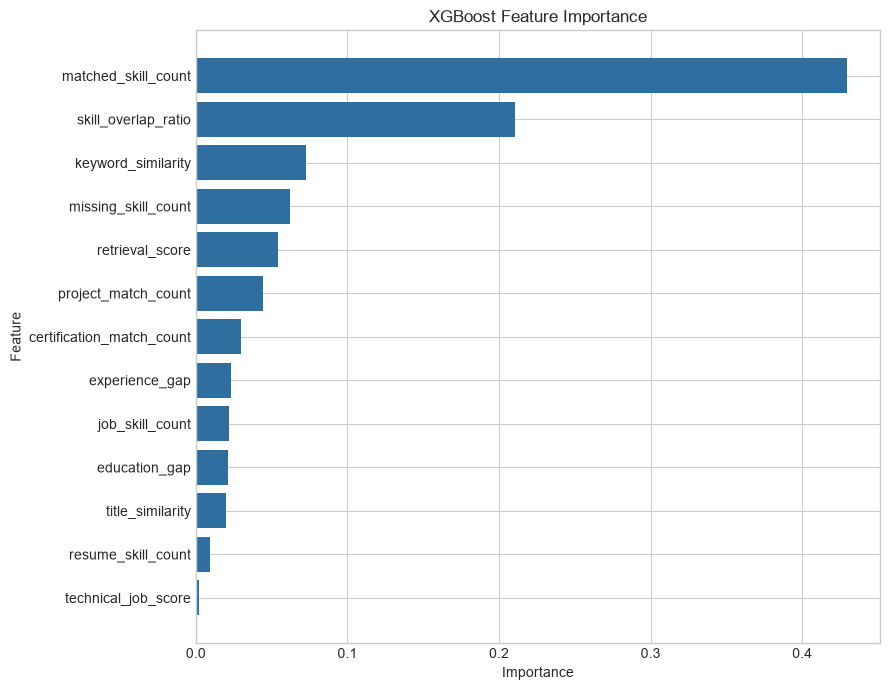

In [83]:
# Cell 16: Feature Importance
# Feature importance highlights which matching signals drive the trained model.
feature_importance = pd.DataFrame(
    {
        "feature": FEATURE_COLUMNS,
        "importance": best_model.feature_importances_,
    }
).sort_values("importance", ascending=False)
feature_importance["importance"] = feature_importance["importance"].round(6)

print("Feature importance table")
display(feature_importance)

fig, ax = plt.subplots(figsize=(9, 7))
plot_data = feature_importance.sort_values("importance", ascending=True)
ax.barh(plot_data["feature"], plot_data["importance"], color="#2f6f9f")
ax.set_title("XGBoost Feature Importance")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

In [84]:
# Cell 17: Threshold Analysis
# Threshold analysis shows the precision-recall trade-off for deployment decisions.
best_probabilities = best_model.predict_proba(X_test)[:, 1]
thresholds = [0.40, 0.50, 0.60, 0.70]
threshold_rows = []

for threshold in thresholds:
    threshold_predictions = (best_probabilities >= threshold).astype(int)
    threshold_rows.append(
        {
            "threshold": threshold,
            "precision": precision_score(y_test, threshold_predictions, zero_division=0),
            "recall": recall_score(y_test, threshold_predictions, zero_division=0),
            "f1": f1_score(y_test, threshold_predictions, zero_division=0),
        }
    )

threshold_analysis = pd.DataFrame(threshold_rows).round(4)
display(threshold_analysis)

,threshold,precision,recall,f1
0,0.4,0.9968,1.0,0.9984
1,0.5,0.9968,1.0,0.9984
2,0.6,0.9968,1.0,0.9984
3,0.7,0.9968,1.0,0.9984


,train_size,train_roc_auc_mean,train_roc_auc_std,validation_roc_auc_mean,validation_roc_auc_std
0,334,1.0,0.0,0.9959,0.0015
1,668,1.0,0.0,0.9993,0.0004
2,1003,1.0,0.0,0.9996,0.0004
3,1337,1.0,0.0,0.9999,0.0001
4,1672,1.0,0.0,0.9999,0.0001


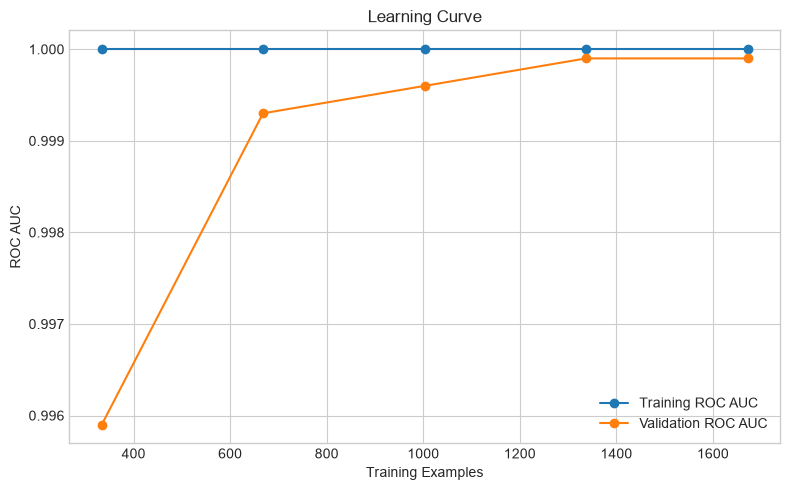

In [85]:
# Cell 18: Learning Curve
# The dataset is small enough for a 5-point, 3-fold learning curve.
learning_curve_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_SEED,
    n_jobs=1,
    tree_method="hist",
    **best_parameters,
)

train_sizes, train_scores, validation_scores = learning_curve(
    estimator=learning_curve_model,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.20, 1.00, 5),
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED),
    scoring="roc_auc",
    n_jobs=1,
)

learning_curve_data = pd.DataFrame(
    {
        "train_size": train_sizes,
        "train_roc_auc_mean": train_scores.mean(axis=1),
        "train_roc_auc_std": train_scores.std(axis=1),
        "validation_roc_auc_mean": validation_scores.mean(axis=1),
        "validation_roc_auc_std": validation_scores.std(axis=1),
    }
).round(4)

display(learning_curve_data)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    learning_curve_data["train_size"],
    learning_curve_data["train_roc_auc_mean"],
    marker="o",
    label="Training ROC AUC",
)
ax.plot(
    learning_curve_data["train_size"],
    learning_curve_data["validation_roc_auc_mean"],
    marker="o",
    label="Validation ROC AUC",
)
ax.set_title("Learning Curve")
ax.set_xlabel("Training Examples")
ax.set_ylabel("ROC AUC")
ax.legend()
plt.tight_layout()
plt.show()

In [86]:
# Cell 19: GroupKFold Generalization Test
# Experiment A: Group by resume_name — tests generalization to unseen resumes.
# Experiment B: Group by job_id — tests generalization to unseen jobs.
# Note: With only 70 resumes and 98 jobs, scores may drop vs standard CV.
# This is expected and represents a better estimate of real-world generalization.

def run_group_kfold(X_full, y_full, groups, group_name, n_splits=5):
    """Run GroupKFold cross-validation and return per-fold metrics."""
    n_unique_groups = groups.nunique()
    actual_splits = min(n_splits, n_unique_groups)
    if actual_splits < 2:
        print(f"  WARNING: Only {n_unique_groups} unique groups for {group_name}. Skipping.")
        return None

    gkf = GroupKFold(n_splits=actual_splits)
    fold_metrics = []

    for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X_full, y_full, groups)):
        X_tr, X_te = X_full.iloc[train_idx], X_full.iloc[test_idx]
        y_tr, y_te = y_full.iloc[train_idx], y_full.iloc[test_idx]

        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_SEED,
            n_jobs=-1,
            tree_method="hist",
            **best_parameters,
        )
        model.fit(X_tr, y_tr, verbose=False)
        y_pred = model.predict(X_te)
        y_proba = model.predict_proba(X_te)[:, 1]

        fold_metrics.append({
            "fold": fold_idx + 1,
            "accuracy": accuracy_score(y_te, y_pred),
            "precision": precision_score(y_te, y_pred, zero_division=0),
            "recall": recall_score(y_te, y_pred, zero_division=0),
            "f1": f1_score(y_te, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_te, y_proba),
            "test_size": len(y_te),
        })

    return pd.DataFrame(fold_metrics)


# Need full dataset for grouping (not just train split)
X_full = dataset[FEATURE_COLUMNS].copy()
y_full = dataset[LABEL_COLUMN].astype(int).copy()

# Experiment A: Group by resume_name
print("=" * 60)
print("Experiment A: GroupKFold by resume_name")
print("=" * 60)
groups_resume = dataset["resume_name"]
print(f"Unique resumes: {groups_resume.nunique()}")
gkf_resume_results = run_group_kfold(X_full, y_full, groups_resume, "resume_name")
if gkf_resume_results is not None:
    display(gkf_resume_results.round(4))
    print(f"\nMean metrics (resume grouping):")
    display(gkf_resume_results.drop(columns=["fold", "test_size"]).mean().round(4).to_frame("mean").T)

# Experiment B: Group by job_id
print()
print("=" * 60)
print("Experiment B: GroupKFold by job_id")
print("=" * 60)
groups_job = dataset["job_id"].astype(str)
print(f"Unique jobs: {groups_job.nunique()}")
gkf_job_results = run_group_kfold(X_full, y_full, groups_job, "job_id")
if gkf_job_results is not None:
    display(gkf_job_results.round(4))
    print(f"\nMean metrics (job grouping):")
    display(gkf_job_results.drop(columns=["fold", "test_size"]).mean().round(4).to_frame("mean").T)

# Comparison summary
print()
print("=" * 60)
print("GroupKFold Comparison Summary")
print("=" * 60)
comparison_rows = []
if gkf_resume_results is not None:
    means = gkf_resume_results.drop(columns=["fold", "test_size"]).mean()
    comparison_rows.append({"experiment": "GroupKFold by resume_name", **means.to_dict()})
if gkf_job_results is not None:
    means = gkf_job_results.drop(columns=["fold", "test_size"]).mean()
    comparison_rows.append({"experiment": "GroupKFold by job_id", **means.to_dict()})

# Add standard CV for comparison
comparison_rows.append({
    "experiment": "Standard 5-Fold CV",
    "accuracy": cv_summary.loc["accuracy", "mean"],
    "precision": cv_summary.loc["precision", "mean"],
    "recall": cv_summary.loc["recall", "mean"],
    "f1": cv_summary.loc["f1", "mean"],
    "roc_auc": cv_summary.loc["roc_auc", "mean"],
})

comparison_df = pd.DataFrame(comparison_rows).set_index("experiment").round(4)
display(comparison_df)

print()
print("Note: resume_name and job_id are used ONLY for grouping.")
print("They are never used as model features because they are identifiers,")
print("not predictive signals. Including them would cause data leakage.")

Experiment A: GroupKFold by resume_name
Unique resumes: 70


,fold,accuracy,precision,recall,f1,roc_auc,test_size
0,1,0.9984,0.9969,1.000,0.9984,1.0000,629
1,2,0.9952,0.9939,0.997,0.9954,1.0000,627
2,3,1.0000,1.0000,1.000,1.0000,1.0000,627
3,4,0.9920,0.9842,1.000,0.9921,0.9996,626
4,5,1.0000,1.0000,1.000,1.0000,1.0000,627



Mean metrics (resume grouping):


,accuracy,precision,recall,f1,roc_auc
mean,0.9971,0.995,0.9994,0.9972,0.9999



Experiment B: GroupKFold by job_id
Unique jobs: 98


,fold,accuracy,precision,recall,f1,roc_auc,test_size
0,1,0.9984,1.0000,0.9969,0.9984,1.0000,628
1,2,1.0000,1.0000,1.0000,1.0000,1.0000,627
2,3,0.9968,0.9946,1.0000,0.9973,0.9999,627
3,4,1.0000,1.0000,1.0000,1.0000,1.0000,627
4,5,0.9984,0.9958,1.0000,0.9979,1.0000,627



Mean metrics (job grouping):


,accuracy,precision,recall,f1,roc_auc
mean,0.9987,0.9981,0.9994,0.9987,1.0



GroupKFold Comparison Summary


,accuracy,precision,recall,f1,roc_auc
experiment,,,,,
GroupKFold by resume_name,0.9971,0.9950,0.9994,0.9972,0.9999
GroupKFold by job_id,0.9987,0.9981,0.9994,0.9987,1.0000
Standard 5-Fold CV,0.9944,0.9921,0.9968,0.9944,0.9996



Note: resume_name and job_id are used ONLY for grouping.
They are never used as model features because they are identifiers,
not predictive signals. Including them would cause data leakage.


Brier Score: 0.0019
Calibration is satisfactory. No additional calibration needed.


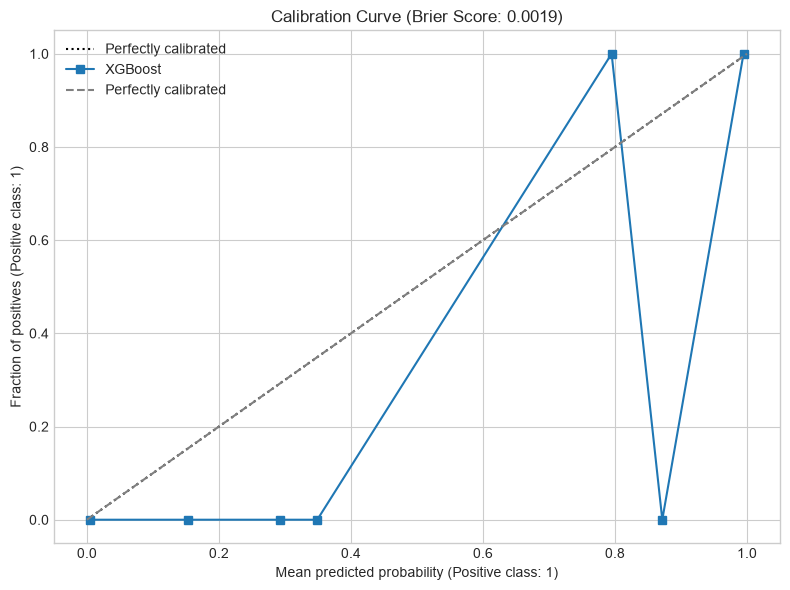

In [87]:
# Cell 20: Probability Calibration Analysis
# XGBoost on balanced datasets typically has reasonable calibration.
# Brier Score < 0.12 indicates calibration is satisfactory.
best_probabilities = best_model.predict_proba(X_test)[:, 1]
brier = brier_score_loss(y_test, best_probabilities)

print(f"Brier Score: {brier:.4f}")
if brier < 0.12:
    print("Calibration is satisfactory. No additional calibration needed.")
else:
    print("Calibration may benefit from Platt scaling or isotonic regression.")

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    n_bins=10,
    strategy="uniform",
    ax=ax,
    name="XGBoost",
)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
ax.set_title(f"Calibration Curve (Brier Score: {brier:.4f})")
ax.legend()
plt.tight_layout()
plt.show()

In [88]:
# Cell 19: Save Model
# Persist the trained estimator and exact feature order for backend inference.
MODEL_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(best_model, MODEL_PATH)
joblib.dump(FEATURE_COLUMNS, FEATURE_COLUMNS_PATH)

saved_artifacts = pd.DataFrame(
    {
        "artifact": ["model", "feature_columns"],
        "path": [str(MODEL_PATH), str(FEATURE_COLUMNS_PATH)],
    }
)

display(saved_artifacts)

,artifact,path
0,model,D:\Projects\RecruitIQ\backend\app\models\xgboo...
1,feature_columns,D:\Projects\RecruitIQ\backend\app\models\featu...


In [89]:
# Cell 22: Final Training Summary
# Consolidated metrics and configuration for final-year project reporting.
final_metrics = best_metrics.copy()
total_training_time = baseline_training_time + tuning_time + best_training_time
train_test_split_text = f"{int((1 - TEST_SIZE) * 100)}/{int(TEST_SIZE * 100)} stratified"
top_features = feature_importance.head(13).copy()

training_summary = pd.DataFrame(
    [
        {"item": "Dataset size", "value": len(dataset)},
        {"item": "Number of features", "value": len(FEATURE_COLUMNS)},
        {"item": "Train/Test split", "value": train_test_split_text},
        {"item": "Train rows", "value": len(X_train)},
        {"item": "Test rows", "value": len(X_test)},
        {"item": "Unique resumes", "value": dataset["resume_name"].nunique()},
        {"item": "Unique jobs", "value": dataset["job_id"].nunique()},
        {"item": "Cross Validation Accuracy", "value": round(cv_summary.loc["accuracy", "mean"], 4)},
        {"item": "CV Accuracy Std", "value": round(cv_summary.loc["accuracy", "standard_deviation"], 4)},
        {"item": "Best CV ROC AUC", "value": round(randomized_search.best_score_, 4)},
        {"item": "Final Accuracy", "value": round(final_metrics["accuracy"], 4)},
        {"item": "Final Precision", "value": round(final_metrics["precision"], 4)},
        {"item": "Final Recall", "value": round(final_metrics["recall"], 4)},
        {"item": "Final F1", "value": round(final_metrics["f1"], 4)},
        {"item": "Final ROC AUC", "value": round(final_metrics["roc_auc"], 4)},
        {"item": "Brier Score", "value": round(brier, 4)},
        {"item": "Training Time Seconds", "value": round(total_training_time, 2)},
        {"item": "Model Path", "value": str(MODEL_PATH)},
    ]
)

print("Training summary")
display(training_summary)

print("Best parameters")
display(pd.DataFrame([best_parameters]).T.rename(columns={0: "value"}))

print("Feature importance (all 13 features)")
display(top_features)



Training summary


,item,value
0,Dataset size,3136
1,Number of features,13
2,Train/Test split,80/20 stratified
3,Train rows,2508
4,Test rows,628
5,Unique resumes,70
6,Unique jobs,98
7,Cross Validation Accuracy,0.9944
8,CV Accuracy Std,0.003
9,Best CV ROC AUC,1.0


Best parameters


,value
colsample_bytree,0.836821
gamma,0.392588
learning_rate,0.045958
max_depth,5.000000
min_child_weight,1.000000
n_estimators,250.000000
subsample,0.957982


Feature importance (all 13 features)


,feature,importance
0,matched_skill_count,0.429789
4,skill_overlap_ratio,0.210535
11,keyword_similarity,0.072439
1,missing_skill_count,0.061889
9,retrieval_score,0.054267
7,project_match_count,0.044423
8,certification_match_count,0.029762
5,experience_gap,0.023337
3,job_skill_count,0.021923
6,education_gap,0.020894
